# Main Code to carry out blocking statistics and diagnostics on model data (CESM+others) and observations

### Specific Code to:
#### 1. Setup the analysis to be done and data to be ingested
#### 2. Climatology plots
#### 3. Jet latitude index
#### 4. 1D Frequency plots
#### 5. 2d Frequency plots
#### 6. PDF of blocking strengths
#### 7. Composite of plots conditioned on blocking strength
#### 8. PDF of blocking/baroclinic events length

In [4]:
import importlib
import blocking_utils as block_utils
import blocking_figs  as block_figs

%load_ext autoreload
%autoreload 2

In [5]:
from dask.distributed import Client
from dask_jobqueue import PBSCluster

In [6]:
cluster = PBSCluster(
    account="P03010039",
    interface="ext",
    walltime="12:00:00",
    queue="main",   
    cores=4,
    memory="32GB",
    processes=4,      # one process per core (safe default)cesm2
    local_directory="/glade/derecho/scratch/rneale/dask-temp",
    log_directory="/glade/derecho/scratch/rneale/dask-logs"
)

cluster.scale(jobs=32)
client = Client(cluster)

client

/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34007 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Compute/proxy/34007/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Compute/proxy/34007/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.174:42555,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Compute/proxy/34007/status,Total threads: 0
Started: Just now,Total memory: 0 B



# TOP LEVEL OPTIONS


In [27]:
ens_names   = ['ERA5', 'MERRA', 'CESM1', 'CESM2',
               'b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315',
               'b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.316']
ens_mem_num = [1, 1, 30, 30, 1, 1]
ens_ystart  = ['1979'] * len(ens_names)
ens_yend    = ['2005'] * len(ens_names)

block_season   = 'DJF'
cam_var        = 'Z500'
block_diag_set = ['1D', '2D']    # which diagnostics to compute


# MAIN ROUTINES


In [28]:
importlib.reload(block_utils) # Required because I am constantly editing utility routines.

# Grab basic ens+run information and populate a dictionary)
block_meta = block_utils.ens_setup(ens_names,ens_mem_num,ens_ystart,ens_yend)

 
++ Large ensemble =  CESM1 :  30  out of  42  total (first/last) ++
b.e11.B20TRC5CNBDRD.f09_g16.001
b.e11.B20TRC5CNBDRD.f09_g16.030
 
++ Large ensemble =  CESM2 :  30  out of  50  total (first/last) ++
b.e21.BHISTcmip6.f09_g17.LE2-1001.001
b.e21.BHISTcmip6.f09_g17.LE2-1251.010


# Grab daily datasets needed for each 'ensemble'

In [29]:
ensemble_ds = block_utils.dataset_get(block_meta, cam_var, block_season)

dataset_get: season=DJF
  ERA5: 1 member(s)  1979–2005
/glade/work/rneale/data/ERA5/Z500.day.mean.nc
  MERRA: 1 member(s)  1979–2005
/glade/work/rneale/data/MERRA/Z500.day.mean.nc
  CESM1: 30 member(s)  1979–2005
/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/atm/proc/tseries/daily/Z500/b.e11.B20TRC5CNBDRD.f09_g16.001.cam.h1.Z500.18500101-20051231.nc
/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/atm/proc/tseries/daily/Z500/b.e11.B20TRC5CNBDRD.f09_g16.002.cam.h1.Z500.19200101-20051231.nc
/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/atm/proc/tseries/daily/Z500/b.e11.B20TRC5CNBDRD.f09_g16.003.cam.h1.Z500.19200101-20051231.nc
/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/atm/proc/tseries/daily/Z500/b.e11.B20TRC5CNBDRD.f09_g16.004.cam.h1.Z500.19200101-20051231.nc
/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/atm/proc/tseries/daily/Z500/b.e11.B20TRC5CNBDRD.f09_g16.005.cam.h1.Z500.19200101-20051231.nc
/glade/campaign/cesm/collections/cesm

#  Calculate/Read/Write blocking frequency: 1D

In [30]:
ensemble_block_1d = block_utils.block_z500_freq(block_meta,ensemble_ds,block_season,block_diag = '1D', file_opts = 'w')

  block_z500_freq: 1D blocking for ERA5
  Writing block_1D_ERA5_nens.1_1979-2005_DJF.nc
    ERA5: blocking 1.97–22.94%  (1.2s)
  block_z500_freq: 1D blocking for MERRA
  Writing block_1D_MERRA_nens.1_1979-2005_DJF.nc
    MERRA: blocking 1.56–22.04%  (4.4s)
  block_z500_freq: 1D blocking for CESM1
  Writing block_1D_CESM1_nens.30_1979-2005_DJF.nc
    CESM1: blocking 1.40–20.58%  (12.2s)
  block_z500_freq: 1D blocking for CESM2
  Writing block_1D_CESM2_nens.30_1979-2005_DJF.nc
    CESM2: blocking 1.44–19.92%  (11.8s)
  block_z500_freq: 1D blocking for b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315
  Writing block_1D_b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315_nens.1_1979-2005_DJF.nc
    b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315: blocking 1.52–19.92%  (2.3s)
  block_z500_freq: 1D blocking for b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.316
  Writing block_1D_b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.316_nens.1_1979-2005_DJF.nc
    b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.316: blocking


# Calculate/Read/Write blocking frequency: 2D


In [31]:
ensemble_block_2d = block_utils.block_z500_freq(block_meta,ensemble_ds,block_season,block_diag = '2D', file_opts = 'w')

  block_z500_freq: 2D blocking for ERA5
  Writing block_2D_ERA5_nens.1_1979-2005_DJF.nc
    ERA5: blocking 0.00–28.35%  (1.3s)
  block_z500_freq: 2D blocking for MERRA
  Writing block_2D_MERRA_nens.1_1979-2005_DJF.nc
    MERRA: blocking 0.00–84.04%  (2.5s)
  block_z500_freq: 2D blocking for CESM1
  Writing block_2D_CESM1_nens.30_1979-2005_DJF.nc
    CESM1: blocking 0.00–58.52%  (10.9s)
  block_z500_freq: 2D blocking for CESM2
  Writing block_2D_CESM2_nens.30_1979-2005_DJF.nc
    CESM2: blocking 0.00–23.50%  (12.7s)
  block_z500_freq: 2D blocking for b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315
  Writing block_2D_b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315_nens.1_1979-2005_DJF.nc
    b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315: blocking 0.00–76.13%  (1.3s)
  block_z500_freq: 2D blocking for b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.316
  Writing block_2D_b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.316_nens.1_1979-2005_DJF.nc
    b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.316: blocking


# Plot 1D blocking: Shade = 1,2 +/- std (or min to max range)


  Saved: /glade/u/home/rneale/python/python-figs/block_1d_freq_ERA5_MERRA_CESM1_CESM2_b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315_b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.316_1979-2005_DJF.png
block_plot_1d: done in 0.2s


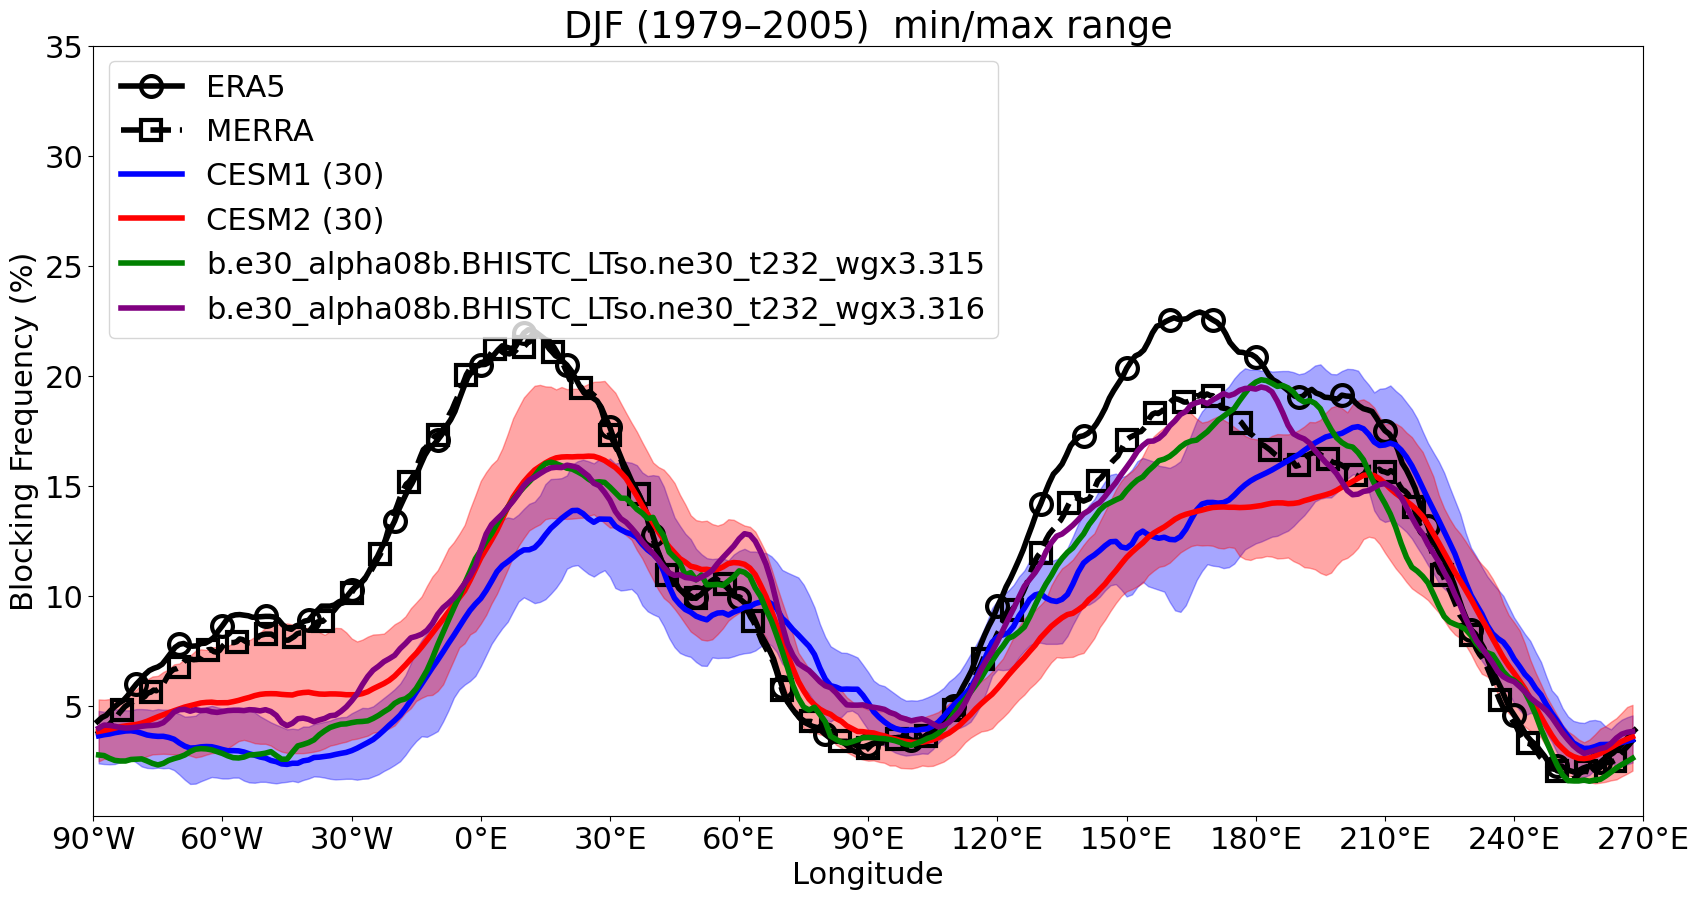

In [32]:
block_figs.block_plot_1d(block_meta,ensemble_block_1d,block_season,fig_out=True)


# Plot 2D blocking: Ensemble ave, 1 ensemble member, or all ensemble members 


  Saved: /glade/u/home/rneale/python/python-figs/block_2d_freq_ERA5_MERRA_CESM1_CESM2_b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.315_b.e30_alpha08b.BHISTC_LTso.ne30_t232_wgx3.316_1979-2005_DJF.png


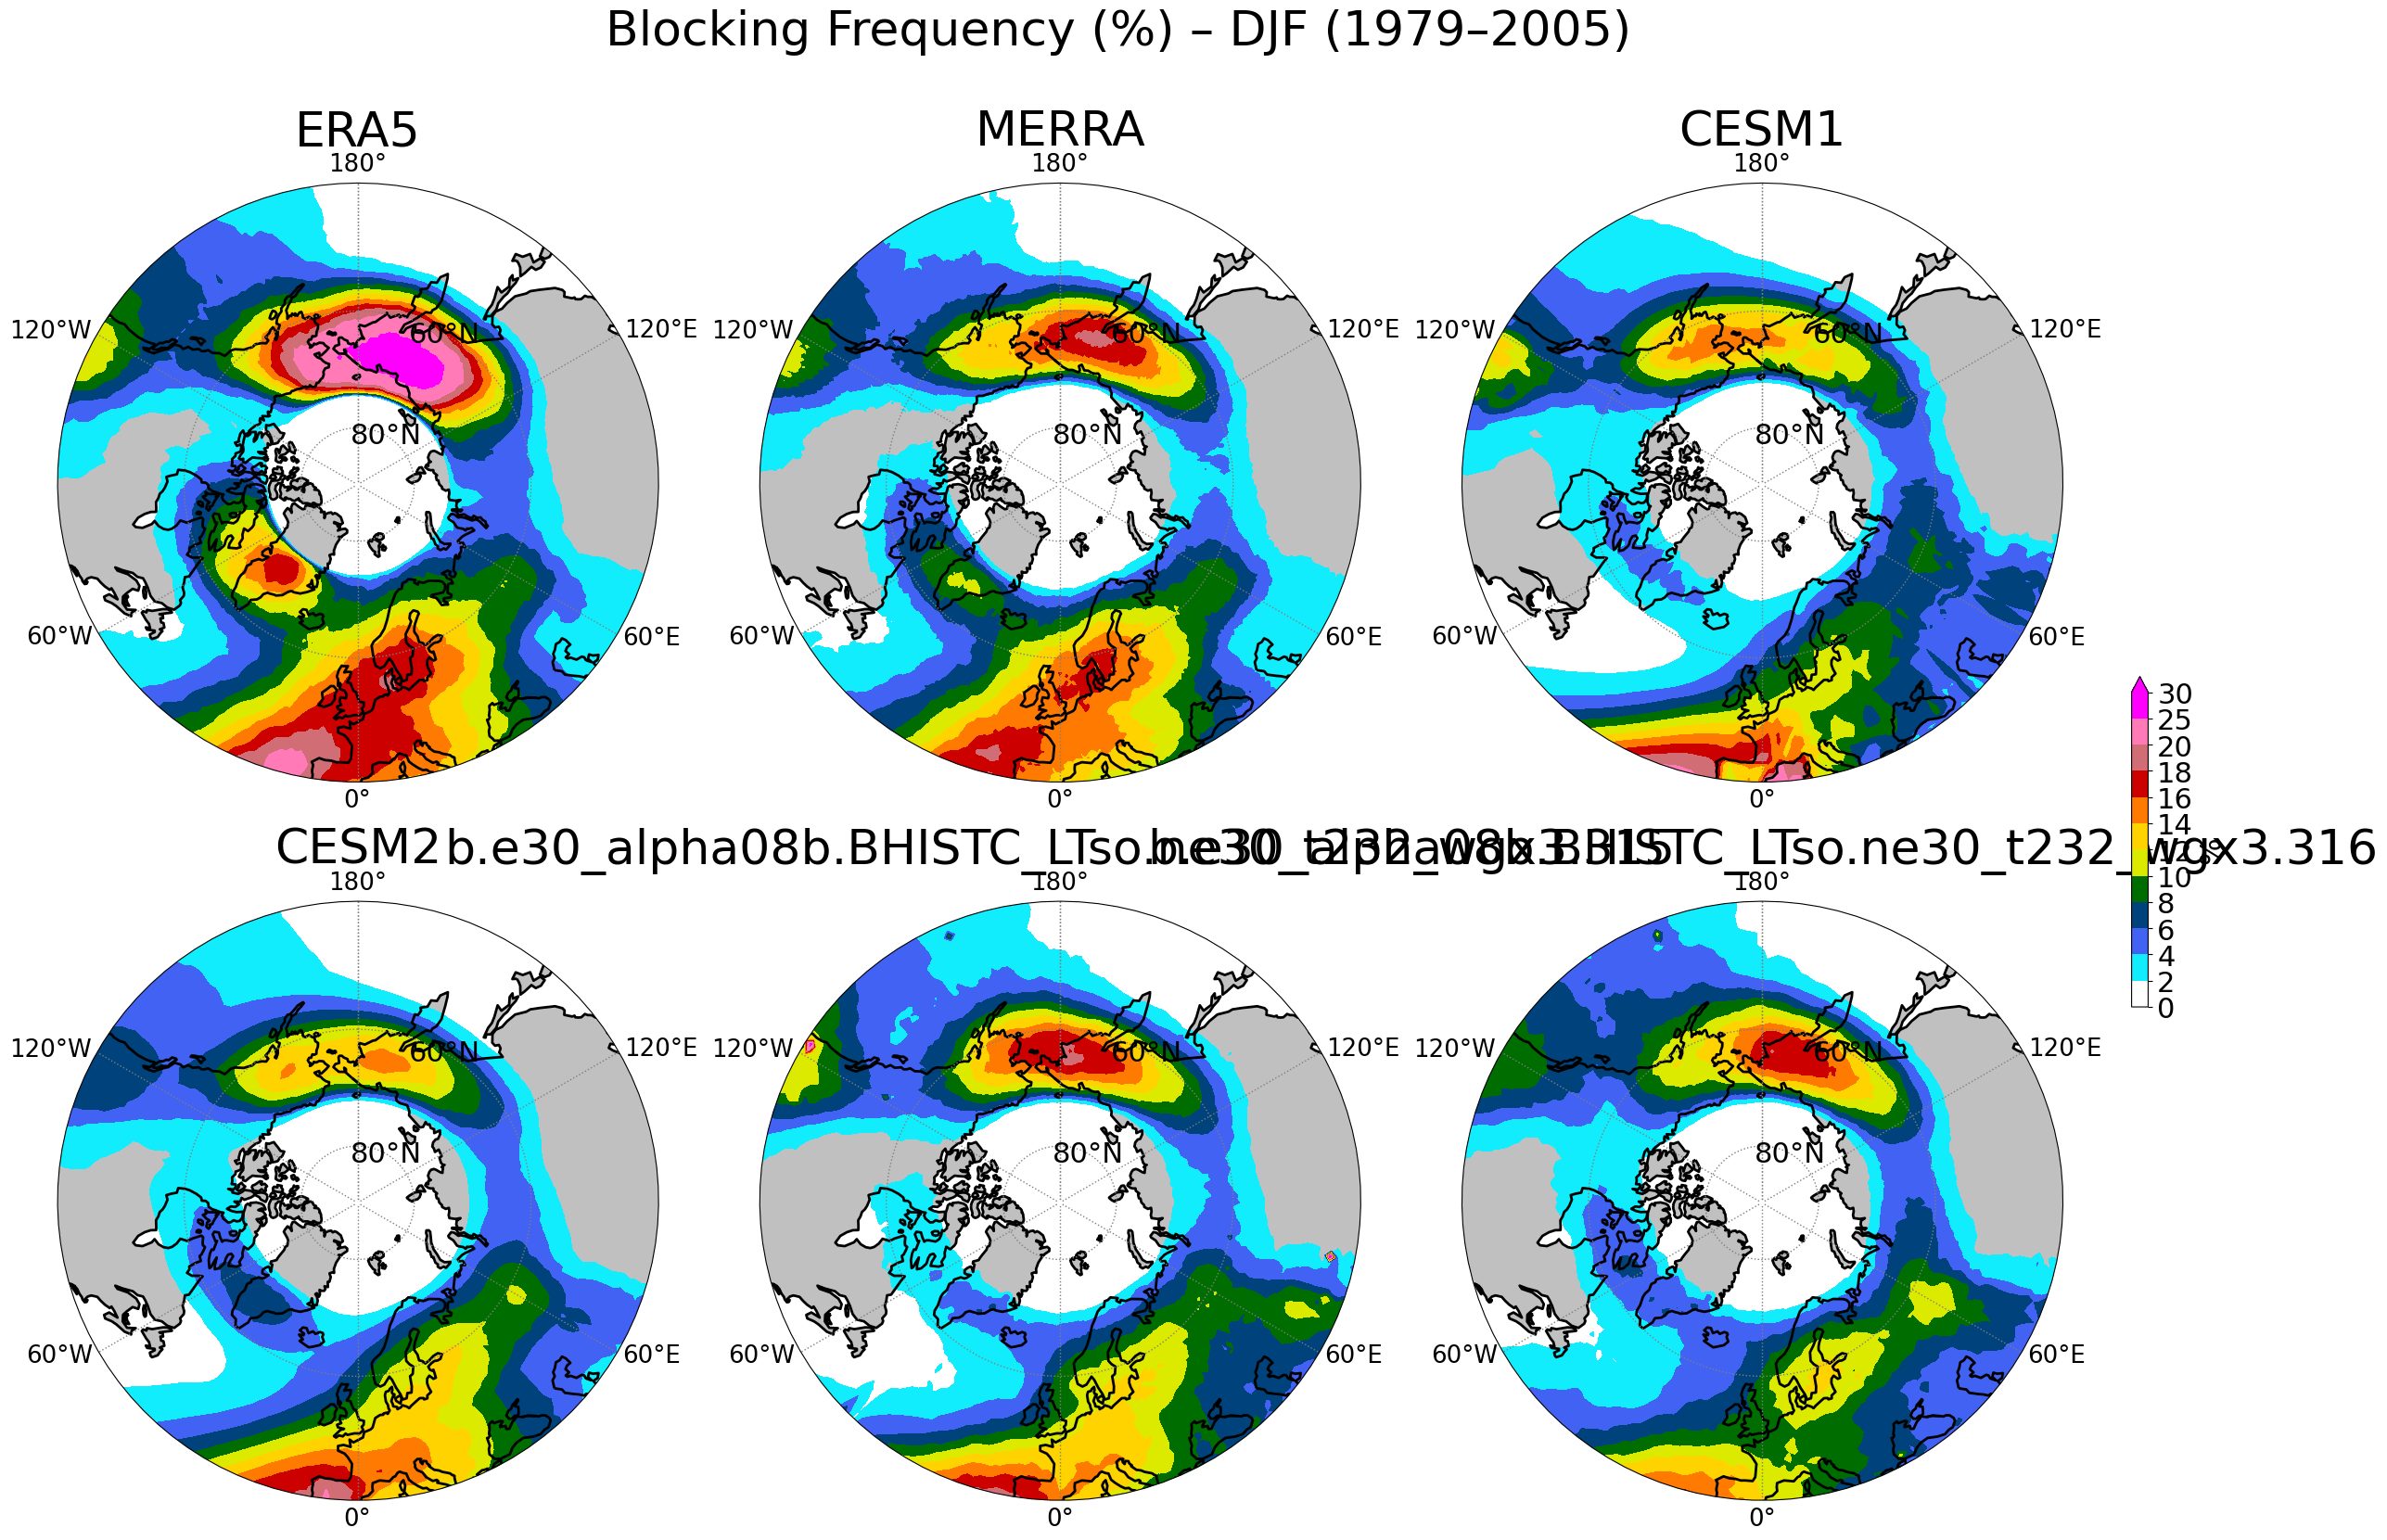

In [33]:
block_figs.block_plot_2d(block_meta,ensemble_block_2d,block_season,fig_out=True,ens_plot='av')


# Plot 1d regional blocking PDFs (European, Pacific and Greenland)


In [ ]:
block_figs.block_plot_1d(block_meta, ensemble_block_1d, block_season,
                         pshade='1', fig_out=True)

In [ ]:
#bstats = atmos_block.stats
#bclimo = atmos_block.climo
#bjet_lat = atmos_block.get_lat
#bfreq_1d = atmos_block.bfreq_1d
#bfreq_2d = atmos_block.bfreq_2d
#bpdf_1d = atmos_block.bfreq_2d
#bcomp_lag = atmos_block.bfreq_lag
#bday_len = atmos_block.bday_len